# Gaia DR4 EAS orbit fit: HD 114762

This notebook fits Gaia source **3937211745905473024** using the prerelease epoch astrometry in `orbitize/example_data`.

**Data credit: ESA/Gaia/DPAC.** See the [DR4 prerelease](https://www.cosmos.esa.int/web/gaia/dr4-prerelease), [data provenance](../../orbitize/example_data/gaia_dr4_eas_README.md).


In [1]:
from pathlib import Path
import sys

repo_root = Path("../..").resolve()
sys.path.insert(0, str(repo_root))

import corner
import numpy as np
import matplotlib.pyplot as plt
from astropy import constants as const, units as u
from astropy.table import Table

import orbitize
from orbitize import gaia, priors, read_input, sampler, system
rng = np.random.default_rng(42)

In [2]:
## EAS DATASET PATH

source_id = 3937211745905473024 # this is HD 114762
xml_path = Path(orbitize.DATADIR) / "GAIA_DR4_PRERELEASE_EPOCH_ASTROMETRY_RAW.xml"
data = read_input.from_dl2(xml_path, source_id)
print(f"{len(data)} CCD measurements in {len(np.unique(data['transit_id']))} transits")
data[:5]


558 CCD measurements in 63 transits


obs_time_tcb,centroid_pos_al,centroid_pos_error_al,scan_pos_angle,used_by_agis_al,source_id,transit_id,ra0,dec0,parallax_factor_al,component_index,field_of_view
d,mas,mas,rad,,,,deg,deg,,,
float64,float64,float32,float64,bool,int64,int64,float64,float64,float32,int64,int64
57529.2860096976,149.97289074186108,0.13584055,0.21236557184986204,True,3937211745905473024,51726035219400196,198.0792922757309,17.517123799636206,0.4134746,1,1
57529.28606589772,150.05527192401016,0.12742461,0.21236833341542563,True,3937211745905473024,51726035219400196,198.0792922757309,17.517123799636206,0.4134746,2,1
57529.28612214583,150.0775337725696,0.12738733,0.21237109744371835,True,3937211745905473024,51726035219400196,198.0792922757309,17.517123799636206,0.4134746,3,1
57529.28617839379,150.13091685375846,0.11294841,0.2123738606056493,True,3937211745905473024,51726035219400196,198.0792922757309,17.517123799636206,0.4134746,4,1
57529.28623464312,150.2786658109899,0.113210775,0.21237662201096255,True,3937211745905473024,51726035219400196,198.0792922757309,17.517123799636206,0.4134746,5,1


In [3]:
# Collapse the AGIS-used CCD measurements to one measurement per transit.
# This follows the bootstrap reduction suggested by Tim Brandt

# full table
native = Table.read(xml_path, format="votable")
# pick our target
native = native[native["source_id"] == source_id]

# copy data
ipd_by_transit = {
    int(row["transit_id"]): np.asarray(row["ipd_error_al"], dtype=float)
    for row in native
}
data["ipd_error_al"] = np.array([
    ipd_by_transit[int(transit_id)][int(component)]
    for transit_id, component in zip(data["transit_id"], data["component_index"])
]) * u.mas


# bootstrap: we're gonna "join" the CCD measurements for a single scan.
# we will randomly draw a median from the 63 scans 500x, make that median the median for an epoch, then make the stdev of the draws
# the uncertainty. the error floor is the median of errors / sqrt (# of ccd measurements).

n_boot = 500
bootstrap_rng = np.random.default_rng(source_id)

transit_rows = []
for ccd in data.group_by("transit_id").groups:
    first = ccd[0] # this one is the sky mapper
    positions = np.asarray(ccd["centroid_pos_al"], dtype=float)
    ipd_errors = np.asarray(ccd["ipd_error_al"], dtype=float)
    n_ccd = len(ccd)

    samples = bootstrap_rng.choice(positions, size=(n_boot, n_ccd), replace=True)
    bootstrap_error = np.std(np.median(samples, axis=1), ddof=1)
    # set error floor so we don't underestimate uncertainty
    error_floor = np.median(ipd_errors) / np.sqrt(n_ccd)
    transit_error = max(bootstrap_error, error_floor)

    transit_rows.append((
        source_id, int(first["transit_id"]), np.mean(ccd["obs_time_tcb"]),
        np.median(positions), transit_error, first["parallax_factor_al"],
        first["scan_pos_angle"], first["field_of_view"], n_ccd,
    ))

ccd_data = data
data = Table(
    rows=transit_rows,
    names=("source_id", "transit_id", "obs_time_tcb", "centroid_pos_al",
           "centroid_pos_error_al", "parallax_factor_al", "scan_pos_angle",
           "field_of_view", "n_ccd"),
)
for name, unit in {
    "obs_time_tcb": u.day, "centroid_pos_al": u.mas,
    "centroid_pos_error_al": u.mas, "parallax_factor_al": u.dimensionless_unscaled,
    "scan_pos_angle": u.rad,
}.items():
    data[name].unit = unit
data.meta.update(time_format="mjd", time_scale="tcb",
                 input_format="eas_prerelease", observation_level="transit")

print(f"Reduced {len(ccd_data)} CCD measurements to {len(data)} transits")
data[:5]


Reduced 558 CCD measurements to 63 transits


source_id,transit_id,obs_time_tcb,centroid_pos_al,centroid_pos_error_al,parallax_factor_al,scan_pos_angle,field_of_view,n_ccd
,,d,mas,mas,,rad,,
int64,int64,float64,float64,float64,float32,float64,int64,int64
3937211745905473024,24802890040890569,57042.39327123151,636.4529204959446,0.06984634935600467,0.62862575,2.690962467446171,1,9
3937211745905473024,24806982339047820,57042.467284882354,633.3128823749879,0.2553608753891642,0.62627935,2.6933800091465336,2,9
3937211745905473024,25770673211715860,57059.89656679212,-872.574127198288,0.1015097125992866,-0.42005676,-2.4772894862011494,1,9
3937211745905473024,25774765523006216,57059.97057966452,-876.4758945341842,0.04426594609966546,-0.4227789,-2.4737075745329875,2,9
3937211745905473024,31060936308474318,57155.568969797154,643.7818597616758,0.03647561730756172,0.2121155,0.5387092530958906,2,8


## Model

Each bootstrapped scan enters the likelihood with variance `transit_error**2 + jitter**2`.


In [4]:
ref_epoch_mjd = 57936.375  # J2017.5, MJD(TCB)
time_mjd = np.asarray(data["obs_time_tcb"], dtype=float)

# along scan + al uncert + scan angle + plx factor
al = np.asarray(data["centroid_pos_al"], dtype=float)
al_err = np.asarray(data["centroid_pos_error_al"], dtype=float)
psi = np.asarray(data["scan_pos_angle"], dtype=float)
parallax_factor = np.asarray(data["parallax_factor_al"], dtype=float)
dt_yr = (time_mjd - ref_epoch_mjd) / 365.25

# thanks simbad
dr3_plx = 26.1979  # mas
dr3_plx_err = 0.1082  # mas

sinpsi = np.sin(psi)
cospsi = np.cos(psi)

# Weighted least-squares starting values for the linear astrometric parameters
design = np.column_stack([
    sinpsi,                 # dra*
    cospsi,                 # ddec
    dt_yr * sinpsi,         # pmra*
    dt_yr * cospsi,         # pmdec
    parallax_factor,        # parallax
])

A = design / al_err[:, None]
b = al / al_err

linear_start, *_ = np.linalg.lstsq(A, b, rcond=None)

linear_names = [
    "dr4_ra_off",
    "dr4_dec_off",
    "dr4_pmra",
    "dr4_pmdec",
    "plx",
]

linear_start = dict(zip(linear_names, linear_start))
linear_names = ["dr4_ra_off", "dr4_dec_off", "dr4_pmra", "dr4_pmdec"]


In [5]:
# Create dr4 log prob
dr4 = gaia.DR4LogProb(
    source_id, data, ref_epoch_mjd=ref_epoch_mjd,
    jitter_prior=priors.LogUniformPrior(1e-4, 100),
)

# Give it some fake relastro so it doesn't break
empty_data = Table(
    names=("epoch", "object", "quant1", "quant1_err", "quant2", "quant2_err",
           "quant12_corr", "quant_type", "instrument"),
    dtype=(float, int, float, float, float, float, float, "U5", "U8"),
)

# set up system
my_sys = system.System( 1, empty_data, stellar_or_system_mass=1.07, mass_err=0.07,
    plx=dr3_plx, plx_err=dr3_plx_err, fit_secondary_mass=True,
    gaia=dr4, tau_ref_epoch=ref_epoch_mjd, fitting_basis="Standard",
)
idx = my_sys.param_idx

# 0.3 - 500 MJup prior
m1_min = (0.3 * u.Mjup).to_value(u.Msun)
m1_max = (500 * u.Mjup).to_value(u.Msun)

for name, prior in {
    "sma1": priors.UniformPrior(0, 1),
    "ecc1": priors.UniformPrior(0, 0.99),
    "inc1": priors.SinPrior(),
    "aop1": priors.UniformPrior(0, 2 * np.pi),
    "pan1": priors.UniformPrior(0, 2 * np.pi),
    "tau1": priors.UniformPrior(0, 1),
    "m1": priors.LogUniformPrior(m1_min, m1_max),
    "dr4_ra_off": priors.UniformPrior(-100, 100),
    "dr4_dec_off": priors.UniformPrior(-100, 100),
    "dr4_pmra": priors.UniformPrior(-2000, 2000),
    "dr4_pmdec": priors.UniformPrior(-2000, 2000),
}.items():
    my_sys.sys_priors[idx[name]] = prior


## Sample the posterior

We will set a "warm start" the cold chain at the supplied mass, eccentricity, inclination, and linear astrometric solution. Orbitize needs a small cloud rather than one identical point for every walker. The orbital angles and phase, and all hotter chains, remain drawn from the broad priors above.


In [10]:
num_temps = 5
num_walkers = 100
burn_steps = 1000
num_steps = 5000

mcmc = sampler.MCMC(
    my_sys, num_temps=num_temps, num_walkers=num_walkers, num_threads=10,
)

# warm start for the cold chain
warm_pos = mcmc.curr_pos[0] if mcmc.use_pt else mcmc.curr_pos
n_start = warm_pos.shape[0]

def set_cloud(name, center, sigma, bounds=None, log=False):
    if log:
        values = np.exp(rng.normal(np.log(center), sigma, n_start))
    else:
        values = rng.normal(center, sigma, n_start)
    if bounds is not None:
        values = np.clip(values, bounds[0], bounds[1])
    warm_pos[:, mcmc.sampled_param_idx[name]] = values

set_cloud("m0", 1.07, 0.01, (0.1, np.inf))
set_cloud("m1", (250 * u.Mjup).to_value(u.Msun),
          (25 * u.Mjup).to_value(u.Msun), (m1_min, m1_max))
set_cloud("sma1", 0.36, 0.02, (1e-6, 1 - 1e-6))
set_cloud("ecc1", 0.10, 0.05, (1e-6, 0.99 - 1e-6))
set_cloud("inc1", 1.00, 0.20, (1e-6, np.pi - 1e-6))
set_cloud("plx", linear_start["plx"], 0.05, (1e-6, np.inf))
set_cloud("dr4_ra_off", 0.0, 0.2, (-100, 100))
set_cloud("dr4_dec_off", 0.0, 0.2, (-100, 100))
set_cloud("dr4_pmra", linear_start["dr4_pmra"], 0.5, (-2000, 2000))
set_cloud("dr4_pmdec", linear_start["dr4_pmdec"], 0.5, (-2000, 2000))
set_cloud("dr4_jitter", 0.1, 0.25, (1e-4, 100), log=True)

run = mcmc.run_sampler(num_walkers * num_steps, burn_steps=burn_steps)
full_chain = run.chain[0].transpose(1, 0, 2)  # cold chain: steps, walkers, parameters
post = mcmc.results.post  # Orbitize stores the cold-temperature posterior
cold_acceptance = np.mean(run.acceptance_fraction[0])
print(f"{num_steps} production steps; cold-chain acceptance={cold_acceptance:.3f}")


Starting Burn in


/Users/clary/Projects/orbitize/orbitize/priors.py:564: RuntimeWarning: invalid value encountered in log
  lnprob = np.log(np.sin(element_array) / normalization)
/Users/clary/Projects/orbitize/orbitize/priors.py:416: RuntimeWarning: invalid value encountered in log
  lnprob = -np.log((element_array * normalizer))
/Users/clary/Projects/orbitize/orbitize/priors.py:564: RuntimeWarning: invalid value encountered in log
  lnprob = np.log(np.sin(element_array) / normalization)
/Users/clary/Projects/orbitize/orbitize/priors.py:416: RuntimeWarning: invalid value encountered in log
  lnprob = -np.log((element_array * normalizer))
/Users/clary/Projects/orbitize/orbitize/priors.py:416: RuntimeWarning: invalid value encountered in log
  lnprob = -np.log((element_array * normalizer))
/Users/clary/Projects/orbitize/orbitize/priors.py:416: RuntimeWarning: invalid value encountered in log
  lnprob = -np.log((element_array * normalizer))
/Users/clary/Projects/orbitize/orbitize/priors.py:416: RuntimeWarn

1000/1000 steps of burn-in complete
Burn in complete. Sampling posterior now.
5000/5000 steps completed
Run complete
5000 production steps; cold-chain acceptance=0.196


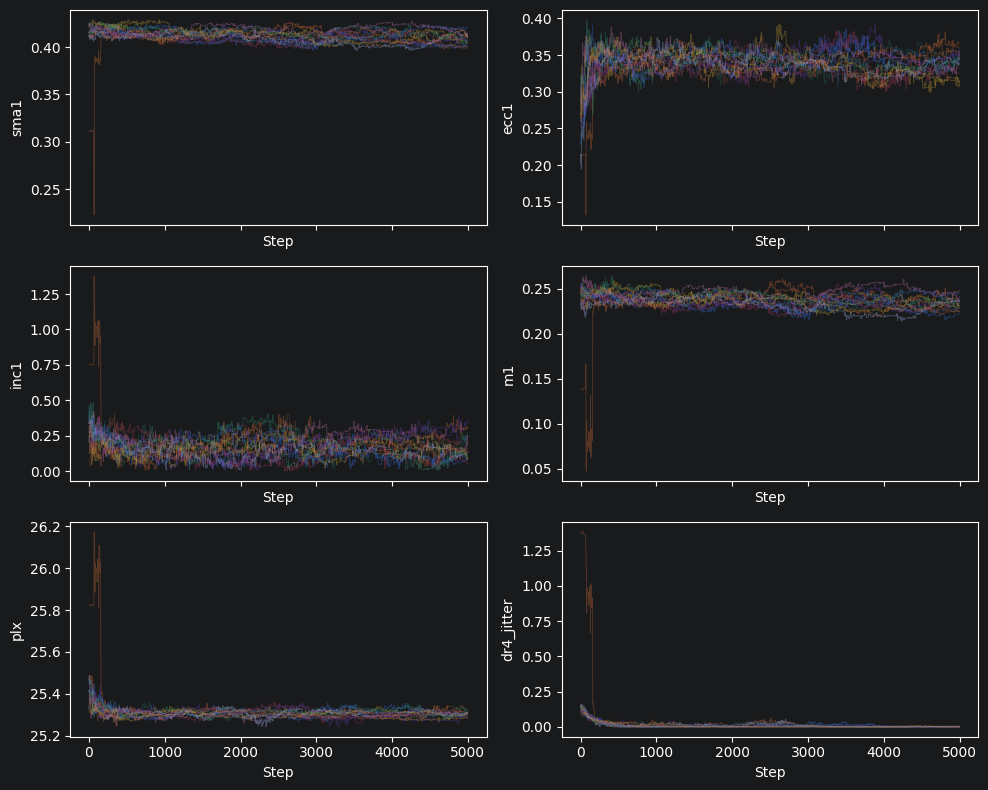

In [11]:

# plot steps for a chain - check convergence
fig, axes = plt.subplots(3, 2, figsize=(10, 8), sharex=True)
for ax, name in zip(axes.flat, ["sma1", "ecc1", "inc1", "m1", "plx", "dr4_jitter"]):
    ax.plot(full_chain[:, :16, mcmc.sampled_param_idx[name]], alpha=0.35, lw=0.6)
    ax.set_ylabel(name)
    ax.set_xlabel("Step")
fig.tight_layout()
plt.show()


In [12]:
total_mass = (post[:, idx["m0"]] + post[:, idx["m1"]]) * u.Msun
period_days = np.sqrt(
    4 * np.pi**2 * (post[:, idx["sma1"]] * u.au)**3 / (const.G * total_mass)
).to_value(u.day)
summary = {
    "period [day]": period_days,
    "eccentricity": post[:, idx["ecc1"]],
    "companion mass [Msun]": post[:, idx["m1"]],
    "inclination [deg]": np.rad2deg(post[:, idx["inc1"]]),
    "jitter [mas]": post[:, idx["dr4_jitter"]],
}
for name, values in summary.items():
    p16, median, p84 = np.percentile(values, [16, 50, 84])
    print(f"{name:25s} {median:.5f}  (16–84%: {p16:.5f}, {p84:.5f})")


period [day]              83.90323  (16–84%: 83.88531, 83.92100)
eccentricity              0.34075  (16–84%: 0.32703, 0.35398)
companion mass [Msun]     0.23726  (16–84%: 0.22937, 0.24628)
inclination [deg]         9.49648  (16–84%: 5.30598, 14.15433)
jitter [mas]              0.00229  (16–84%: 0.00027, 0.01844)


## Orbitize plots


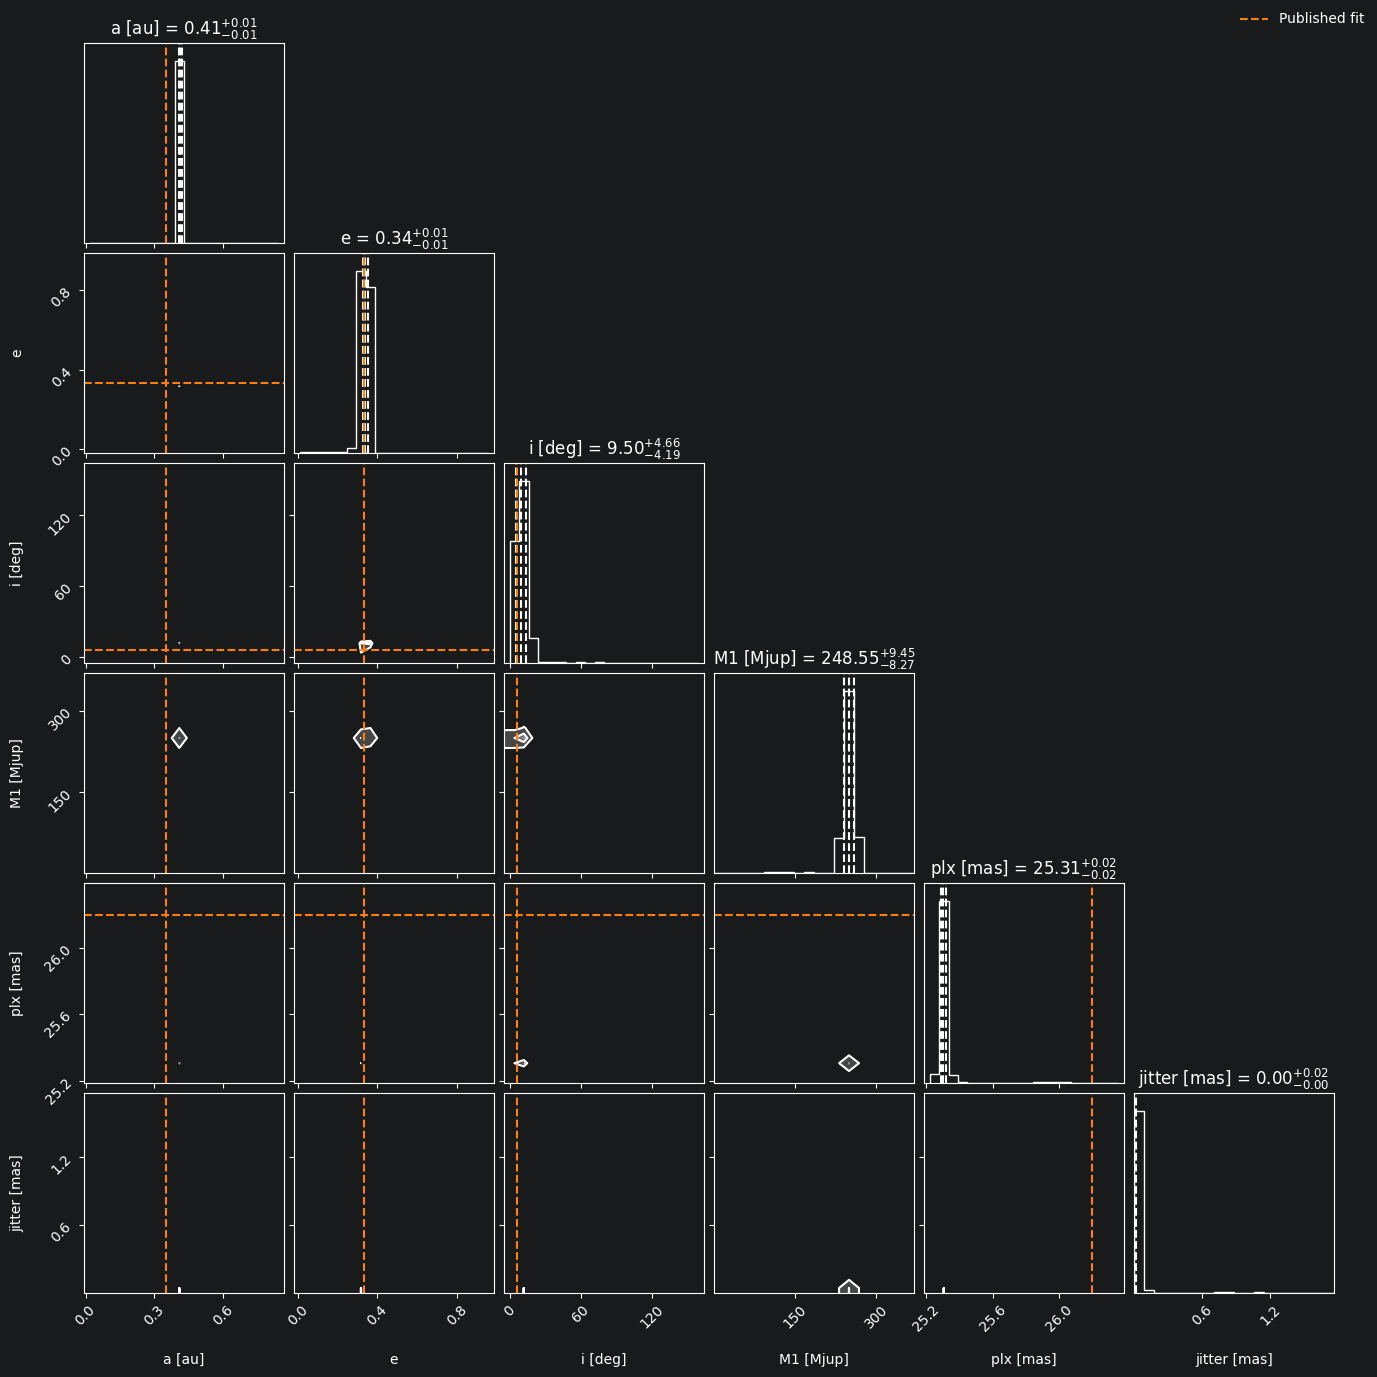

In [13]:
corner_params = ["sma1", "ecc1", "inc1", "m1", "plx", "dr4_jitter"]
corner_figure = mcmc.results.plot_corner(
    param_list=corner_params,
    labels=["a [au]", "e", "i [deg]", "M1 [Mjup]", "plx [mas]", "jitter [mas]"],
    quantiles=[0.16, 0.5, 0.84], show_titles=True,
    plot_datapoints=False, fill_contours=True, max_n_ticks=3,
)

# compare to published values https://exoplanet.eu/catalog/hd_114762_a_b--65/
published_fit = [0.353, 0.3354, 6.2, None, dr3_plx, None]
corner.overplot_lines(
    corner_figure, published_fit, color="tab:orange",
    linestyle="--", linewidth=1.5, label="Published fit",
)

# Keep a reference visible even when it lies outside the posterior range.
axes = np.asarray(corner_figure.axes).reshape(len(corner_params), len(corner_params))
for dim, value in enumerate(published_fit):
    if value is None:
        continue
    for ax in axes[dim:, dim]:
        lo, hi = min(ax.get_xlim()[0], value), max(ax.get_xlim()[1], value)
        ax.set_xlim(lo - 0.03 * (hi - lo), hi + 0.03 * (hi - lo))
    for ax in axes[dim, :dim]:
        lo, hi = min(ax.get_ylim()[0], value), max(ax.get_ylim()[1], value)
        ax.set_ylim(lo - 0.03 * (hi - lo), hi + 0.03 * (hi - lo))
corner_figure.legend(
    *corner_figure.axes[0].get_legend_handles_labels(),
    loc="upper right", frameon=False,
)
plt.show()


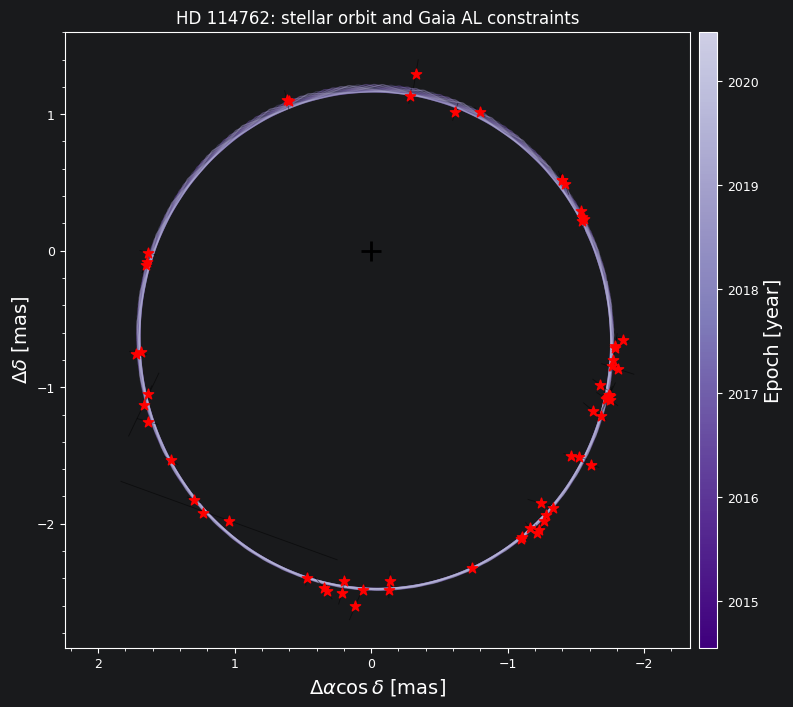

In [14]:
from copy import copy


best_idx = np.nanargmax(mcmc.results.lnlike)
best_results = copy(mcmc.results)
best_results.post = mcmc.results.post[[best_idx]]
best_results.lnlike = mcmc.results.lnlike[[best_idx]]

orbit_figure = best_results.plot_dr4_orbit(
    my_sys, num_orbits_to_plot=1, num_epochs_to_plot=500, fontsize=14,
)
orbit_figure.axes[0].set_title("HD 114762: stellar orbit and Gaia AL constraints")
plt.show()
